This notebook implements and evaluates the XGBoost classifier for bearing fault diagnosis.

Objectives:

- Train an XGBoost model
- Evaluate classification performance
- Compare against Random Forest
- Prepare results for dissertation evaluation

# Install XGBoost

In [2]:
!pip install xgboost

In [3]:
import xgboost
print(xgboost.__version__)

3.3.0


# Imports

In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

# Load Dataset

In [5]:
df = pd.read_csv(
    "phase1_full_dataset.csv"
)

print(df.shape)

(6153, 25)


# Define Features

In [6]:
X = df.drop(
    columns=[
        "Label",
        "Source_File",
        "RPM"
    ],
    errors="ignore"
)

y = df["Label"]

groups = df["Source_File"]

# Leakage-Free Split

In [7]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Verify No Leakage

In [8]:
train_files = set(
    groups.iloc[train_idx]
)

test_files = set(
    groups.iloc[test_idx]
)

print(
    train_files.intersection(
        test_files
    )
)

set()


# Train XGBoost

In [9]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# Predictions

In [10]:
xgb_pred = xgb_model.predict(
    X_test
)

# Accuracy

In [11]:
accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    accuracy
)

XGBoost Accuracy: 0.998730964467005


# Classification Report

In [12]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1891
           1       1.00      0.99      1.00       235
           2       1.00      1.00      1.00       238

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



# Confusion Matrix

In [13]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm)

[[1891    0    0]
 [   2  233    0]
 [   1    0  237]]


# Plot Confusion Matrix

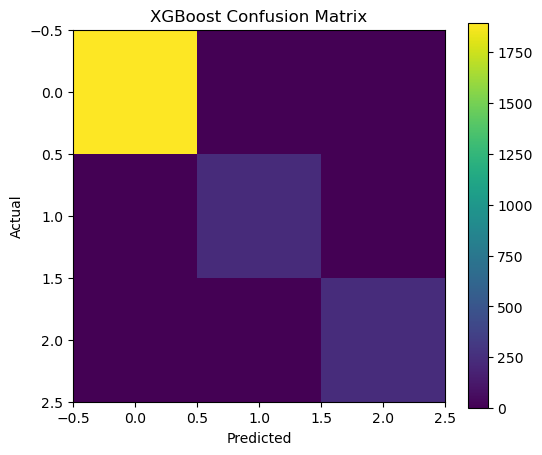

In [14]:
plt.figure(
    figsize=(6,5)
)

plt.imshow(cm)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

# Feature Importance

In [15]:
importance = pd.DataFrame(
{
    "Feature":
        X.columns,

    "Importance":
        xgb_model.feature_importances_
}
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,Peak,0.299724
4,Peak_to_Peak,0.285102
18,Band_1000_2000,0.235593
16,Band_0_500,0.118681
1,RMS,0.035745
21,Wavelet_D3,0.020430
22,Wavelet_D4,0.001228
7,Crest_Factor,0.001010
14,Amp_BSF,0.000677
8,Shape_Factor,0.000557


# Top 10 Features Plot

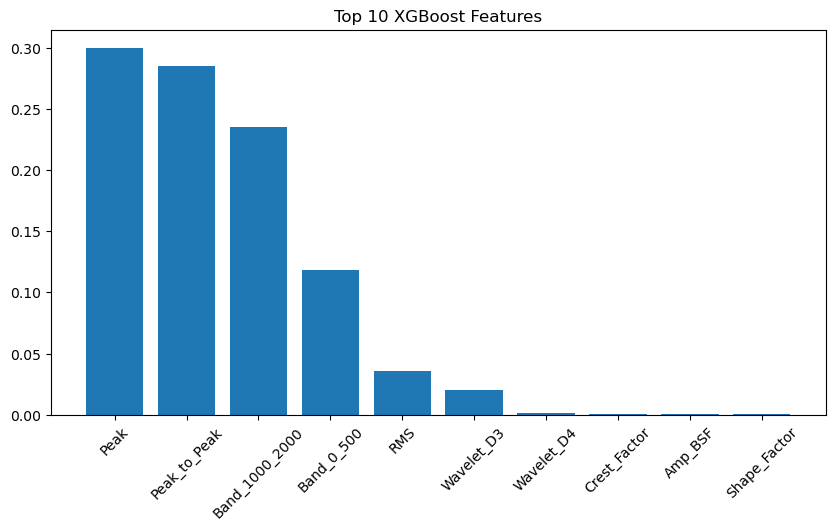

In [16]:
top10 = importance.head(10)

plt.figure(
    figsize=(10,5)
)

plt.bar(
    top10["Feature"],
    top10["Importance"]
)

plt.xticks(
    rotation=45
)

plt.title(
    "Top 10 XGBoost Features"
)

plt.show()

# Model Comparison

In [17]:
comparison = pd.DataFrame(
{
    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        1.0,
        accuracy
    ]
}
)

comparison

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.998731


# Save Results

In [18]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print(
    "Results saved."
)

Results saved.
